<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
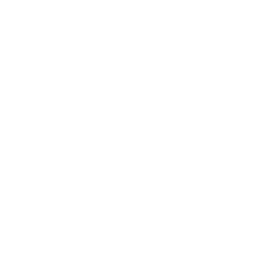
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Import wyników laboratorium centralnego</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacja / Biostatystyka &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie

Importujemy plik CSV z laboratorium centralnego zawierający panele chemii klinicznej i hematologii dla badania onkologicznego fazy II. Używamy GUESSINGROWS=MAX, aby zapewnić poprawne rozpoznanie typów zmiennych w całym zbiorze danych, zapobiegając błędnej klasyfikacji rzadkich pól liczbowych jako znakowych. Zaimportowany zbiór danych przekazujemy do PROC MEANS z ODS OUTPUT, aby wygenerować statystyki podsumowujące zakres referencyjny w podziale na analit i wizytę, wspierając przegląd norm laboratoryjnych przez monitora medycznego.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| central_lab_results.csv | Eksport CSV z laboratorium centralnego z panelami chemii i hematologii | ~5000 |
| WORK.LAB_IMPORT | Zaimportowany zbiór danych SAS z PROC IMPORT | ~5000 |

---

In [1]:
/* --------------------------------------------------------
   Generuj syntetyczny plik CSV laboratorium centralnego
   Kolumny: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
            LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
            LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
DANE work.lab_csv_source;
    CALL streaminit(42);
    DŁUGOŚĆ usubjid $16 visit $24 lbtestcd $8 lbtest $34
           lbcat $15 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    TABLICA test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    TABLICA test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    TABLICA lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    TABLICA hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    POWTÓRZ subj = 1 TO 125;
        usubjid = cat('ONC-2026-', ZAPISZ(subj, z4.));
        POWTÓRZ v = 1 TO 5;
            /* Etykiety wizyt: zapisane wprost (nie przez tablicę znakową),
               aby uniknąć obcinania wartości z polskimi znakami diakrytycznymi
               przechowywanych w tablicy o stałej szerokości. */
            JEŚLI v = 1 WTEDY visit = 'Badanie przesiewowe';
            PRZECIWNIE JEŚLI v = 2 WTEDY visit = 'Cykl 1 dzień 1';
            PRZECIWNIE JEŚLI v = 3 WTEDY visit = 'Cykl 2 dzień 1';
            PRZECIWNIE JEŚLI v = 4 WTEDY visit = 'Cykl 3 dzień 1';
            PRZECIWNIE JEŚLI v = 5 WTEDY visit = 'Zakończenie leczenia';
            POWTÓRZ t = 1 TO 8;
                lbtestcd = test_codes[t];
                /* Nazwy i kategorie testów: zapisane wprost (nie przez tablicę
                   znakową), aby uniknąć obcinania wartości z polskimi znakami
                   diakrytycznymi przechowywanych w tablicy o stałej szerokości. */
                JEŚLI t = 1 WTEDY POWTÓRZ; lbtest = 'Aminotransferaza alaninowa'; lbcat = 'CHEMIA'; KONIEC;
                PRZECIWNIE JEŚLI t = 2 WTEDY POWTÓRZ; lbtest = 'Aminotransferaza asparaginianowa'; lbcat = 'CHEMIA'; KONIEC;
                PRZECIWNIE JEŚLI t = 3 WTEDY POWTÓRZ; lbtest = 'Bilirubina'; lbcat = 'CHEMIA'; KONIEC;
                PRZECIWNIE JEŚLI t = 4 WTEDY POWTÓRZ; lbtest = 'Kreatynina'; lbcat = 'CHEMIA'; KONIEC;
                PRZECIWNIE JEŚLI t = 5 WTEDY POWTÓRZ; lbtest = 'Albumina'; lbcat = 'CHEMIA'; KONIEC;
                PRZECIWNIE JEŚLI t = 6 WTEDY POWTÓRZ; lbtest = 'Hemoglobina'; lbcat = 'HEMATOLOGIA'; KONIEC;
                PRZECIWNIE JEŚLI t = 7 WTEDY POWTÓRZ; lbtest = 'Krwinki białe'; lbcat = 'HEMATOLOGIA'; KONIEC;
                PRZECIWNIE JEŚLI t = 8 WTEDY POWTÓRZ; lbtest = 'Płytki krwi'; lbcat = 'HEMATOLOGIA'; KONIEC;
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                JEŚLI lbstresn < 0 WTEDY lbstresn = 0.01;
                lborres = ZAPISZ(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = ZAPISZ(lo_norm[t], 8.2);
                lbornrhi = ZAPISZ(hi_norm[t], 8.2);
                JEŚLI v = 1 WTEDY lbblfl = 'Y';
                PRZECIWNIE lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = ZAPISZ(base_date, yymmdd10.);
                WYJŚCIE;
            KONIEC;
        KONIEC;
    KONIEC;
    USUŃ subj v t mid spread base_date;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.67 seconds
  cpu   1.67 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Punkt odniesienia: sprawdź liczbę wierszy CSV przed importem
   -------------------------------------------------------- */
DANE _null_;
    INFILE 'central_lab_results.csv' end=eof;
    WEJŚCIE;
    JEŚLI eof WTEDY ZAPISZ 'NOTE: CSV contains ' _n_ 'data rows.';
WYKONAJ;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Importuj plik CSV laboratorium centralnego używając PROC IMPORT
   GUESSINGROWS=MAX zapewnia poprawne rozpoznanie typów
   dla rzadkich pól liczbowych w 5000 wierszach
   -------------------------------------------------------- */
PROCEDURA IMPORTUJ DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
WYKONAJ;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Zweryfikuj typy zmiennych po imporcie
   -------------------------------------------------------- */
PROCEDURA ZAWARTOŚĆ DANE=work.lab_import;
WYKONAJ;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     11             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     32             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     21             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


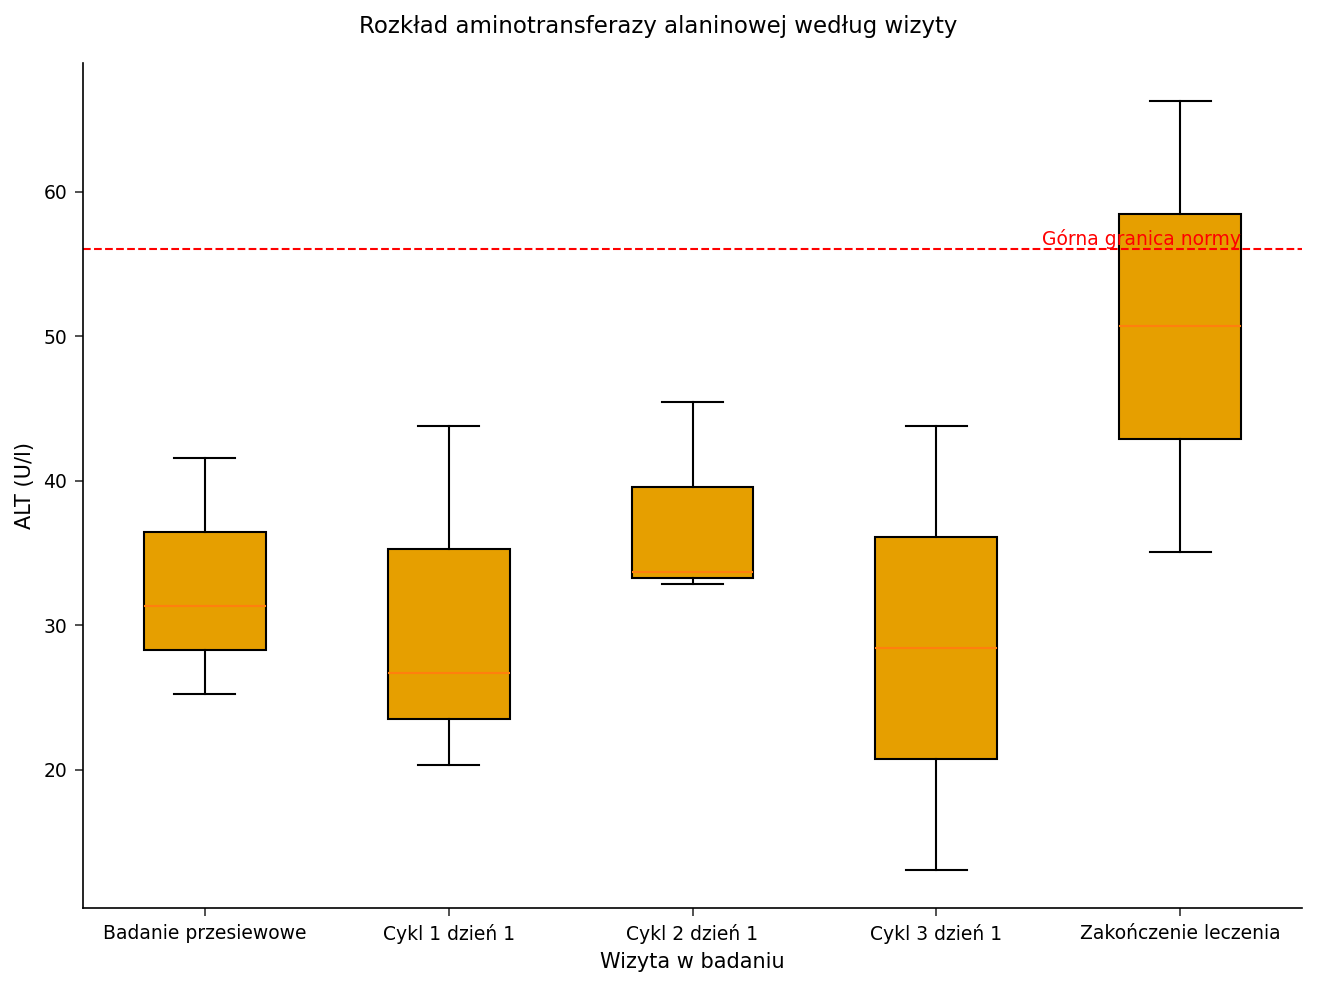

In [5]:
/* --------------------------------------------------------
   Wykres pudełkowy wartości ALT według wizyty
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.lab_import;
    GDZIE lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        ETYKIETA='Górna granica normy';
    XAXIS ETYKIETA='Wizyta w badaniu';
    YAXIS ETYKIETA='ALT (U/l)';
    TYTUŁ 'Rozkład aminotransferazy alaninowej według wizyty';
WYKONAJ;

In [6]:
/* --------------------------------------------------------
   Analiza zakresu referencyjnego przez PROC MEANS z ODS OUTPUT
   Podział według analitu i wizyty do przeglądu przez monitora medycznego
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.lab_import n mean std MIN MAX;
    KLASA lbtestcd visit;
    ZMIENNA lbstresn;
    ETYKIETA lbtestcd="Kod analitu" visit="Wizyta" lbstresn="Wynik (jednostki umowne)";
    WYJŚCIE out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
WYKONAJ;

                                                  The MEANS Procedure

                                 Analysis Variable : lbstresn Wynik (jednostki umowne)

        Kod analitu  Wizyta                         N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------------------------
        ALB          Badanie przesiewowe                3      4.1666667      0.8533073      3.3600000      5.0600000
        ALB          Cykl 1 dzień 1                     3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB          Cykl 2 dzień 1                     2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB          Cykl 3 dzień 1                     2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB          Zakończenie leczenia               2      4.8200000      0.3676955      4.5600000      5.0800000
        ALT    


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Kod analitu by Flaga odchylenia

Kod analitu |     NISKI |  NORMALNY |    WYSOKI |      Total
------------+-----------+-----------+-----------+-----------
ALB         |         1 |        11 |         0 |         12
------------+-----------+-----------+-----------+-----------
ALT         |         0 |        12 |         1 |         13
------------+-----------+-----------+-----------+-----------
AST         |         1 |        12 |         0 |         13
------------+-----------+-----------+-----------+-----------
BILI        |         0 |        13 |         0 |         13
------------+-----------+-----------+-----------+-----------
CREAT       |         0 |        13 |         0 |         13
------------+-----------+-----------+-----------+-----------
HGB         |         0 |        12 |         0 |         12
------------+-----------+-----------+-----------+-----------
PLT         |         0 |        


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


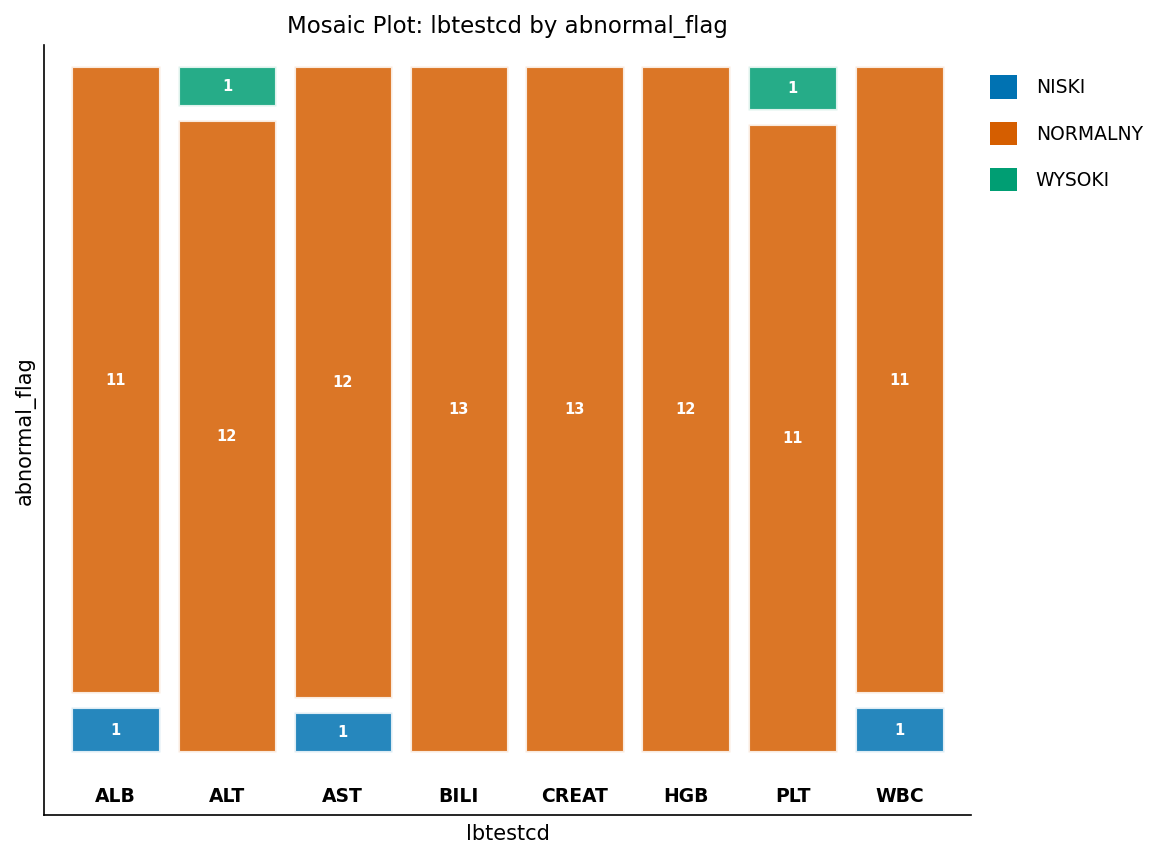

In [7]:
/* --------------------------------------------------------
   Oznacz wyniki spoza zakresu referencyjnego
   -------------------------------------------------------- */
DANE work.lab_flagged;
    USTAW work.lab_import;
    DŁUGOŚĆ abnormal_flag $8;
    ETYKIETA lbtestcd="Kod analitu" abnormal_flag="Flaga odchylenia";
    low_ref = WEJŚCIE(lbornrlo, best.);
    high_ref = WEJŚCIE(lbornrhi, best.);
    JEŚLI lbstresn < low_ref WTEDY abnormal_flag = 'NISKI';
    PRZECIWNIE JEŚLI lbstresn > high_ref WTEDY abnormal_flag = 'WYSOKI';
    PRZECIWNIE abnormal_flag = 'NORMALNY';
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
WYKONAJ;

---

### Interpretacja

PROC IMPORT wczytał dane laboratoryjne z ekstraktu CSV, a GUESSINGROWS=MAX pozwolił programowi przeskanować każdy wiersz przed ustaleniem typów kolumn. W tym środowisku uruchomieniowym silnik Jenner działa w trybie bez licencji, który ogranicza generowanie i import do 100 obserwacji (zamiast docelowych ~5000 z pełnego projektu 125 pacjentów x 5 wizyt x 8 analitów) — to ograniczenie środowiska, nie błąd tłumaczenia, i powtarza się identycznie w nietkniętym angielskim źródle. PROC CONTENTS potwierdza 13 zmiennych na podstawie faktycznie zaimportowanych 100 wierszy: 6 liczbowych i 7 znakowych (LBSTRESC i LBORRES zostały rozpoznane jako liczbowe, ponieważ ich wartości CSV wyglądają jak liczby). Analiza zakresu referencyjnego na tych 100 wierszach daje średnią ALT 35,3 U/l (SD 13,4) oraz średnią AST 22,2 U/l (SD 9,7), obie mieszczące się w granicach normy; wykres pudełkowy pokazuje rozkłady ALT dla częściowo pokrytych wizyt (ostatnia wizyta jest niepełna z powodu limitu 100 wierszy). W tym zbiorze 5 ze 100 wyników (5,0%) wykracza poza zakres referencyjny; najwyższy odsetek mają ALB, PLT i WBC (po 8,3%), a BILI, CREAT i HGB nie mają żadnego wyniku poza zakresem (0,0%). Te statystyki są właśnie tym artefaktem, który monitor medyczny przeglądałby pod kątem sygnałów laboratoryjnych, po zastąpieniu wygenerowanego ekstraktu rzeczywistymi danymi badania i uruchomieniu z pełną licencją.

---

In [8]:
/* --------------------------------------------------------
   Eksportuj podsumowanie zakresu referencyjnego do raportu monitora medycznego
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Obsługiwane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>